# はじめに

このノートでは強化学習を理解するために、「ゼロから作るDeepLearning4(強化学習)」の書籍に従って、強化学習の基礎について理解を深める。ノートの中のコードは書籍のサポートページに記載されているコードを参考にさせて頂く。

- [ゼロから作るDeepLearning4(強化学習)](https://www.oreilly.co.jp/books/9784873119755/)
- [ゼロから作るDeepLearning4(強化学習)のコード](https://github.com/oreilly-japan/deep-learning-from-scratch-4/tree/master)

## 第1章: バンディット問題

強化学習では「エージェント」と「環境」が相互にやりとりすることで学習を進める。エージェントは行動する主体のことで、ロボットであれば、ロボットがエージェントとなる。

「エージェント」は何らかの「環境」におかれ、「環境」の「状態」を観測し、それに基づいて「行動」を起こす。その結果として、「環境」の「状態」が変化し、「エージェント」は「環境」から「報酬」を受け取ると同時にあたらしい「状態」を観測する。これを繰り返して、エージェントが得る「報酬」の総和を最大化することを目標とする。

多腕バンディット問題は、スロットマシンを例に説明がされることが多い。スロットマシンは環境、プレイヤーはエージェントである。多腕が意味しているのは、複数の特性が異なるスロットマシンがあったときに、決められた回数の中で、スロットマシンをプレイしてあたりの回数を最大化する問題といえる。ただ、複数あるスロットマシンの当たり易さをユーザーはわからない。

| スロットマシンの項目             | 強化学習の用語      | 説明                                                         |
|------------------------------|------------------|------------------------------------------------------------|
| プレイヤー                   | エージェント        | 行動を選択し、報酬を得る主体                                 |
| スロットマシン（各台）         | 環境   | エージェントが選択できる選択肢（どのマシンを引くか）         |
| レバーを引く                 | アクション          | エージェントが選択した行動を実際に行うこと                   |
| 当たり・外れ                 | 報酬                | 行動の結果として得られる値（コインが出る＝報酬）             |
| 各スロットマシンの当たりやすさ | 環境の確率分布       | 各行動（マシン）ごとに異なる報酬の確率分布がある             |
| プレイ回数                   | ステップ／エピソード | 試行回数。繰り返し行動を選択し、報酬を得る                   |
| 状態（通常は1つのみ）         | 状態（ステート）     | 多腕バンディット問題では通常状態は1つだけとみなされる         |
| 選び方のルール               | 方策（ポリシー）     | どのスロットマシンをどのように選ぶかのルール                 |

そもそも、スロットマシンの当たり易さをどのように考えられるか。このような問題には確率が利用できる。つまり、実際にはわからないが、各スロットマシンが確率分布表を持つと考える。確率分布表があれば、期待値を考えることで、スロットマシンの良し悪しを比較できる。良さがわかれば、当たりやすいスロットマシンをプレイし続けることで、プレイヤーを報酬を最大化できる。

数式をつかって表すと、報酬はRewardの頭文字をとって$R$、エージェントの行う行動をActionの$A$。報酬Rの期待値は$\mathbb{E}[R]$で表現でき、$A$という行動を選択した時の期待値は、$\mathbb{E}[R|A]$の条件付きで表現される。$A=a$の行動を選んだことを明示する場合は、$\mathbb{E}[R|A=a]$と記載する。行動価値は$q(A)=\mathbb{E}[R|A]$として表される。

このようなバンディット問題をバンディットアルゴリズムでは、どのように解決をするのか。価値の推定方法を考える。プレイヤーは各スロットマシンa,bを3回づつプレイして結果を得たとする。

|スロットマシン|1回目|2回目|3回目|
|:---|:---|:---|:---|
|a|0|1|5|
|b|1|0|0|

この結果をもとに価値を推定する。

$$
\begin{aligned}
Q(a) &= \frac{0+1+5}{3}=2 \\
Q(b) &= \frac{1+0+0}{3}=0.33
\end{aligned}
$$

つまり、結果をもとに平均値を計算することで推定する。一般化すると、スロットマシンを$n$回プレイする場合、得られた報酬$R_{t}$の平均を計算することになる。標本平均である。

$$
\begin{aligned}
Q_{n} &= \frac{R_{1}+R_{2}+...+R_{n}}{n}
\end{aligned}
$$

10回プレイした時の行動価値の推移は下記の通り計算できる。

In [461]:
import numpy as np

# naive implementation
np.random.seed(0)
rewards = []

for n in range(1, 11):
    reward = np.random.rand()
    rewards.append(reward)
    Q = sum(rewards) / n
    print(f"n: {n:02}, Q: {Q}")

n: 01, Q: 0.5488135039273248
n: 02, Q: 0.6320014351498722
n: 03, Q: 0.6222554154571295
n: 04, Q: 0.6029123573420713
n: 05, Q: 0.567060845741438
n: 06, Q: 0.5801997236289743
n: 07, Q: 0.5598265075766483
n: 08, Q: 0.6013198192273272
n: 09, Q: 0.6415801460355164
n: 10, Q: 0.6157662833145425


ただ、この計算方法だと効率が悪いので、1つ前の行動価値の推定値を利用して計算する。1つ前の行動価値の推定値は下記で表せる。

$$
\begin{aligned}
Q_{n-1} = \frac{R_{1}+...+R_{n-1}}{n-1}
\Leftrightarrow R_{1}+...+R_{n-1} = (n-1)Q_{n-1}
\end{aligned}
$$

この関係を使うことで、$Q_{n}$を計算できる。

$$
\begin{aligned}
Q_{n} 
&= \frac{R_{1}+...+R_{n}}{n} \\
&= \frac{1}{n} (R_{1}+...+R_{n-1}+R_{n}) \\
&= \frac{1}{n} \left( (n-1) Q_{n-1} + R_{n} \right) \\
&= \left( 1 - \frac{1}{n} \right) Q_{n-1} + \frac{1}{n} R_{n} \\
&= Q_{n-1} + \frac{1}{n}(R_{n} - Q_{n-1})
\end{aligned}
$$

ここで注目するのは$Q_{n}=Q_{n-1}+...$という形になっており、$n$は$n-1$回目が基準となっている。そして、$\frac{1}{n}(R_{n} - Q_{n-1})$分だけ追加して更新される。ここでの$\frac{1}{n}$は、プレイ回数が多くなればなるほど小さくなり、更新量を調整する。そのため、$\frac{1}{n}$は学習率とも呼ばれる。

In [462]:
# import numpy as np

# np.random.seed(0)
rewards = []
Q = 0  # Q_0 の初期値
for n in range(1, 11):
    R = np.random.rand()
    rewards.append(R)
    print(f"n: {n:02}, Q_before: {Q}, R: {R}")  # 計算前の状態を表示
    Q = Q + (1 / n) * (R - Q)
    print(f"n: {n:02}, Q_after:  {Q}\n")  # 計算後の状態も表示

n: 01, Q_before: 0, R: 0.7917250380826646
n: 01, Q_after:  0.7917250380826646

n: 02, Q_before: 0.7917250380826646, R: 0.5288949197529045
n: 02, Q_after:  0.6603099789177845

n: 03, Q_before: 0.6603099789177845, R: 0.5680445610939323
n: 03, Q_after:  0.6295548396431672

n: 04, Q_before: 0.6295548396431672, R: 0.925596638292661
n: 04, Q_after:  0.7035652893055406

n: 05, Q_before: 0.7035652893055406, R: 0.07103605819788694
n: 05, Q_after:  0.5770594430840099

n: 06, Q_before: 0.5770594430840099, R: 0.08712929970154071
n: 06, Q_after:  0.49540441918693173

n: 07, Q_before: 0.49540441918693173, R: 0.02021839744032572
n: 07, Q_after:  0.4275207017945595

n: 08, Q_before: 0.4275207017945595, R: 0.832619845547938
n: 08, Q_after:  0.4781580947637318

n: 09, Q_before: 0.4781580947637318, R: 0.7781567509498505
n: 09, Q_after:  0.5114912787844116

n: 10, Q_before: 0.5114912787844116, R: 0.8700121482468192
n: 10, Q_after:  0.5473433657306523



$Q_{n-1}$は、過去$n-1$回までの行動価値の推定値で、$n$が多くなると確度が高くなる状態なので、あまり更新量を多くしたくない。$(R_{n} - Q_{n-1})$は実際に得られた報酬からこれまでの行動価値の差分を計算し、正ならば価値を高く更新し、負ならば価値を低く更新する。ただ、プレイ回数が少ないときは、更新量を$\frac{1}{n}$で大きく調整して更新し、プレイ回数が増えると、$\frac{1}{n}$は小さくなるため、更新量は小さくなる。「期待報酬」と「現実報酬」のギャップを埋めるプロセスを経ることで、学習していく。

学習方法はわかったところで、エージェントであるプレイヤーは、どのような戦略を立てることで価値を最大にできるのか。実際にプレイした結果をもとに、各スロットの価値の推定値の中で一番大きい値のスロットマシンを選んでプレイし続ける戦略が挙げられる。これをGreedyな行動と言われる。ただ、あくまでも得られているのは推定値なので、本来は報酬を大きくできるスロットマシンであるにもかかわらず、そのスロットマシンを選ばない、ということに繋がる場合もある。この不確かさに対して、活用と探索をうまく組み合わせることで、対処する必要がある。

- 活用：プレイ結果を利用して、最善と思われるスロットマシンをプレイ=Greedyな行動
- 探索：スロットマシンの価値を精度高く推定するために様々なスロットマシンをプレイすること

そのため、強化学習のアルゴリズムは「活用と探索」のバランスをいかに取れるか、という部分に行き着くことになる。その中でももっとも基本的なアルゴリズムがε-Greedy法。ε-Greedy法では$\epsilon$の確率で「探索」を行い、それ以外は「活用」を行うアルゴリズム。ここでは、1000回プレイするという条件の中で、10台のスロットマシンが別々の確率で勝率が設定されている状態を仮定する。シミュレーションでは乱数で勝率を設定することになるが、実際はわからない。ここから勝率が高いスロットマシンを選ぶ必要がある。

In [463]:
import numpy as np
import matplotlib.pyplot as plt


class Bandit:
    def __init__(self, arms=10):
        self.rates = np.random.rand(arms)

    def play(self, arm):
        # 各スロットマシンの勝率を取得
        rate = self.rates[arm]
        if rate > np.random.rand():
            return 1
        else:
            return 0

各スロットマシンの勝率は下記の通りである。

In [464]:
bandit = Bandit()
bandit.rates

array([0.97861834, 0.79915856, 0.46147936, 0.78052918, 0.11827443,
       0.63992102, 0.14335329, 0.94466892, 0.52184832, 0.41466194])

0番目のスロットマシンをプレイする場合は下記の通り。スロットマシンで勝利した場合は1、負けた場合は0が返される。

In [465]:
bandit.play(0)

1

次はエージェントがどのような行動を選択するかを考える。例えば、0番目のスロットマシンをプレイしつ続けた場合の価値の推定方法は下記の通りとなる。

In [466]:
for n in range(1, 11):
    reward = bandit.play(0)
    Q += (reward - Q) / n
    print(round(Q, 2))

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


参考書籍のコードをもとにε-Greedy法を実装したものがこちら。

In [467]:
class Agent:
    def __init__(self, epsilon, action_size=10):
        # 探索確率
        self.epsilon = epsilon
        # 行動価値の推定値を保存
        self.Qs = np.zeros(action_size)
        # 行動回数を保存
        self.ns = np.zeros(action_size)

    # 行動価値の推定値を更新
    def update(self, action, reward):
        # 行動回数を更新
        self.ns[action] += 1
        # 行動価値の推定値を更新
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    # 行動を選択
    def get_action(self):
        # 探索確率が0.1より小さい場合はランダムに行動を選択
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        # それ以外は、行動価値の推定値が最大の行動を選択
        return np.argmax(self.Qs)

1000回の中でどれだけ報酬が得られるかを実際に動かしてみる。

In [468]:
if __name__ == "__main__":
    # ステップ数
    steps = 1000
    # 探索確率
    epsilon = 0.1

    # スロットマシンを生成
    bandit = Bandit()
    # エージェントを生成
    agent = Agent(epsilon)
    # 総報酬を保存
    total_reward = 0
    # 総報酬を保存
    total_rewards = []
    # 勝率を保存
    rates = []

    # ステップ数分繰り返し
    for step in range(steps):
        # 行動を選択
        action = agent.get_action()
        # 報酬を取得
        reward = bandit.play(action)
        # 行動価値の推定値を更新
        agent.update(action, reward)
        # 総報酬を更新
        total_reward += reward
        # 総報酬を保存
        total_rewards.append(total_reward)
        # 勝率を保存
        rates.append(total_reward / (step + 1))
        print(f"スロットマシンNo: {action}")
        print(f"ステップ: {step+1}")
        print("行動回数:", agent.ns)
        print("行動価値推定値:", agent.Qs)

スロットマシンNo: 0
ステップ: 1
行動回数: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
行動価値推定値: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
スロットマシンNo: 0
ステップ: 2
行動回数: [2. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
行動価値推定値: [0.5 0.  0.  0.  0.  0.  0.  0.  0.  0. ]
スロットマシンNo: 0
ステップ: 3
行動回数: [3. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
行動価値推定値: [0.33333333 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
スロットマシンNo: 0
ステップ: 4
行動回数: [4. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
行動価値推定値: [0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
スロットマシンNo: 0
ステップ: 5
行動回数: [5. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
行動価値推定値: [0.4 0.  0.  0.  0.  0.  0.  0.  0.  0. ]
スロットマシンNo: 0
ステップ: 6
行動回数: [6. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
行動価値推定値: [0.33333333 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
スロットマシンNo: 0
ステップ: 7
行動回数: [7. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
行動価値推定値: [0.42857143 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
スロットマシンNo: 0
ステップ: 8
行動回数: [8. 0. 0. 0. 0

`total_reward`には勝利した回数が記録されており、価値の総和の推移は増加傾向にあることがわかる。

644


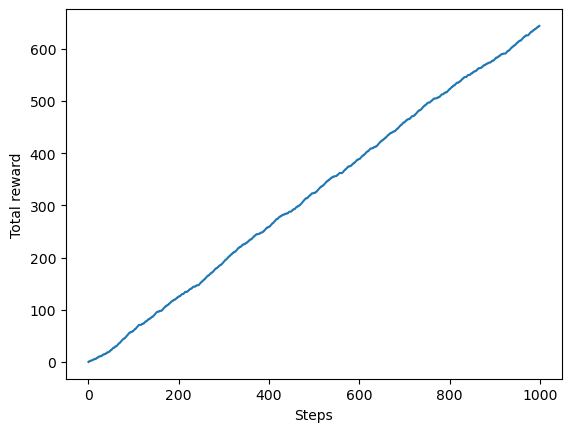

In [469]:
print(total_reward)
plt.ylabel("Total reward")
plt.xlabel("Steps")
plt.plot(total_rewards)
plt.show()

勝率の推移を確認すると、一定回数のステップまでに勝率が上昇し、そこからは一定の勝率で勝ち続けていることがわかる。

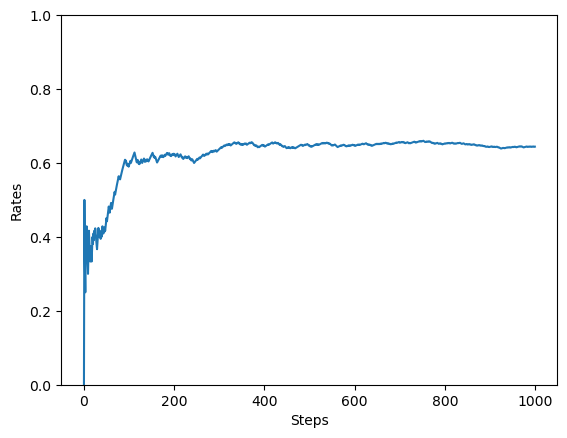

In [470]:
plt.ylabel("Rates")
plt.xlabel("Steps")
plt.plot(rates)
plt.ylim(0, 1)
plt.show()

ただ、この結果はあくまでも実験で得られた1つの結果でしかない。そのため、実験の回数を増やして平均的なアルゴリズムの性能(良さ)を確認するのが良い。下記では1回1000ステップの実験を100回繰り返した平均的な結果である。

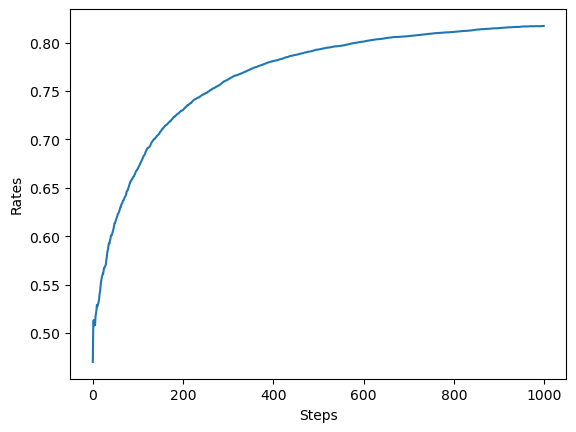

In [471]:
runs = 100
steps = 1000
epsilon = 0.1
all_rates = np.zeros((runs, steps))  # (2000, 1000)

for run in range(runs):
    bandit = Bandit()
    agent = Agent(epsilon)
    total_reward = 0
    rates = []

    for step in range(steps):
        action = agent.get_action()
        reward = bandit.play(action)
        agent.update(action, reward)
        total_reward += reward
        rates.append(total_reward / (step + 1))

    all_rates[run] = rates

avg_rates = np.average(all_rates, axis=0)

plt.ylabel("Rates")
plt.xlabel("Steps")
plt.plot(avg_rates)
plt.show()

実際には各ステップごとの100回の実験で得られた値を平均している。可視化するとわかりよい。例えば1000ステップ目には100本の線があるが、これを平均すると、上図の1000ステップ目の値となる。

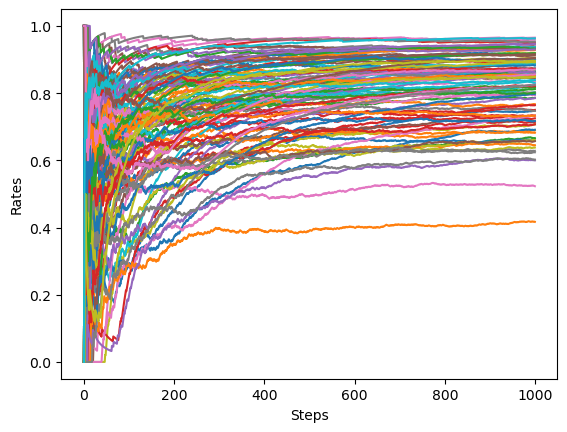

In [472]:
plt.ylabel("Rates")
plt.xlabel("Steps")
for i in range(100):
    plt.plot(all_rates[i])
plt.show()

ε-Greedy法ではεの値によっても、結果はかわってしまう。下記では実験のたびにεをランダムで与えた結果である。結果が大きく異なることがわかる。

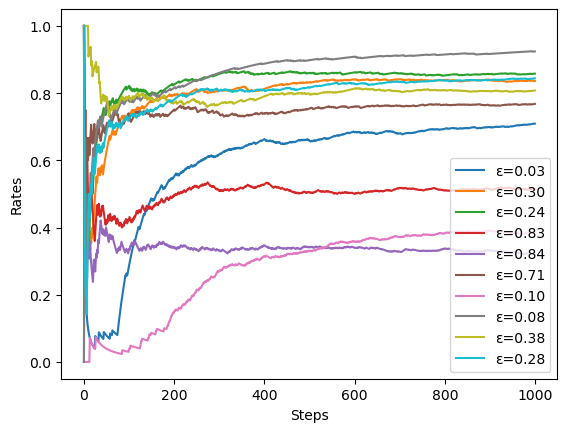

In [473]:
runs = 10
steps = 1000
epsilon = np.random.rand(runs)
all_rates = np.zeros((runs, steps))  # (2000, 1000)

for run in range(runs):
    bandit = Bandit()
    agent = Agent(epsilon[run])
    total_reward = 0
    rates = []

    for step in range(steps):
        action = agent.get_action()
        reward = bandit.play(action)
        agent.update(action, reward)
        total_reward += reward
        rates.append(total_reward / (step + 1))

    all_rates[run] = rates


plt.ylabel("Rates")
plt.xlabel("Steps")
for i in range(runs):
    plt.plot(all_rates[i], label=f"ε={epsilon[i]:.2f}")
    plt.legend()

plt.show()

ここからは「定常/非定常の問題」を扱う。定常とは、報酬の確率分布が変わらない問題のことを指す。つまり、スロットマシンを1000回プレイしても、1000回とも同じしきい値で勝ち負けが判断されている状態。反対に非定常な問題では、報酬の確率分布が変化する問題のことを指す。つまり、同じスロットマシンをプレイしても、勝ち負けの確率がプレイするたびに変わるような状態。これまでの報酬の計算方法は、各ステップでの報酬を均等な重み$1/n$をつけて計算している。

$$
\begin{aligned}
Q_{n-1} &= \frac{R_{1}+...+R_{n}}{n}\\
&= \frac{R_{1}}{n}+\frac{R_{2}}{n}+...+\frac{R_{n}}{n}
\end{aligned}
$$

これは、直近の報酬も1回めの報酬も同じ価値としてみなすことを意味する。非定常問題では、時間とともに環境であるスロットマシンの勝率が変化するため、過去の報酬の重要性は低くなる方が望ましい。そのために行動価値の計算式の$1/n$を$\alpha$とする。こうすことによって、過去に得た報酬の価値は指数関数的に小さくなる。これは$Q_{n}$と$Q_{n-1}$の関係を掘り下げるとわかりよい。

$$
\begin{aligned}
Q_{n} 
&= Q_{n-1} + \frac{1}{n}(R_{n} - Q_{n-1})\\
&= Q_{n-1} + \alpha(R_{n} - Q_{n-1}) \\
&= \alpha R_{n} + Q_{n-1} - \alpha Q_{n-1} \\
&= \alpha R_{n} + (1 - \alpha)Q_{n-1} \\
\end{aligned}
$$

ここで$Q_{n-1}$は$Q_{n-1} = \alpha R_{n-1} + (1 - \alpha)Q_{n-2}$より、代入すると

$$
\begin{aligned}
Q_{n} 
&= \alpha R_{n} + (1 - \alpha)Q_{n-1} \\
&= \alpha R_{n} + (1 - \alpha)\{\alpha R_{n-1} + (1 - \alpha)Q_{n-2} \} \\
&= \alpha R_{n} + \alpha(1 - \alpha) R_{n-1} + (1 - \alpha)^2 Q_{n-2} \\
\end{aligned}
$$

となる。このように重みが指数関数的に減少していく。$n=5$で展開すると下記の通りあり、$n$に対して、遠くなると重みが小さくなっていることがわかる。

$$
\begin{aligned}
Q_{1} &= \alpha R_{1} + (1-\alpha)Q_{0}\\
Q_{2} &= \alpha R_{2} + \alpha(1-\alpha)R_{1} + (1-\alpha)^{2}Q_{0}\\
Q_{3} &= \alpha R_{3} + \alpha(1-\alpha)R_{2} + \alpha(1-\alpha)^{2}R_{1} + (1-\alpha)^{3}Q_{0}\\
Q_{4} &= \alpha R_{4} + \alpha(1-\alpha)R_{3} + \alpha(1-\alpha)^{2}R_{2} + \alpha(1-\alpha)^{3}R_{1} + (1-\alpha)^{4}Q_{0}\\
Q_{5} &= \alpha R_{5} + \alpha(1-\alpha)R_{4} + \alpha(1-\alpha)^{2}R_{3} + \alpha(1-\alpha)^{3}R_{2} + \alpha(1-\alpha)^{4}R_{1} + (1-\alpha)^{5}Q_{0}
\end{aligned}
$$

一般的には下記のように表現できる。これは指数移動平均、指数加重移動平均と呼ばれる。

$$
\begin{aligned}
Q_{n} = \sum_{k=1}^{n} \alpha(1-\alpha)^{n-k} R_{k} +  (1 - \alpha)^{n} Q_{0} 
\end{aligned}
$$

非定常問題に対するバンディットとエージェントのクラスは下記の通り。変更点はプレイするたびにスロットマシンの勝率が変化すること、行動価値の計算方法が少し変わったことの2点。

In [474]:
class NonStatBandit:
    def __init__(self, arms=10):
        self.arms = arms
        self.rates = np.random.rand(arms)

    def play(self, arm):
        rate = self.rates[arm]
        # playメソッドが呼ばれるたびに、報酬の確率分布が変化
        self.rates += 0.1 * np.random.randn(self.arms)  # Add noise
        if rate > np.random.rand():
            return 1
        else:
            return 0


class AlphaAgent:
    def __init__(self, epsilon, alpha, actions=10):
        self.epsilon = epsilon
        self.Qs = np.zeros(actions)
        self.alpha = alpha

    def update(self, action, reward):
        # 行動価値の更新式を1/nではなくαで表現
        self.Qs[action] += (reward - self.Qs[action]) * self.alpha

    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)

非定常の問題に対しては、指数加重移動平均を用いた行動価値の計算方法のほうが平均的に優れていることがわかる。

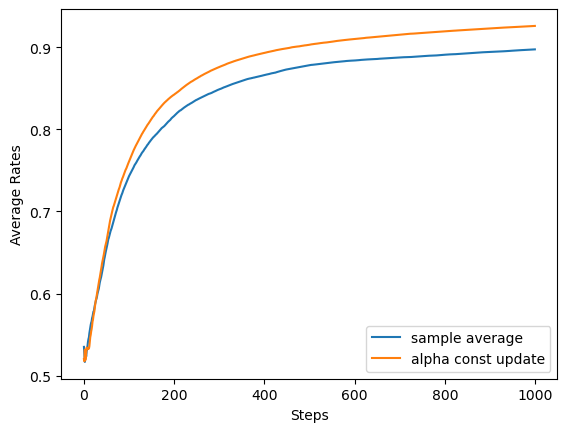

In [475]:
runs = 200
steps = 1000
epsilon = 0.1
alpha = 0.8
agent_types = ["sample average", "alpha const update"]
results = {}

for agent_type in agent_types:
    all_rates = np.zeros((runs, steps))  # (200, 1000)

    for run in range(runs):
        if agent_type == "sample average":
            agent = Agent(epsilon)
        else:
            agent = AlphaAgent(epsilon, alpha)

        bandit = NonStatBandit()
        total_reward = 0
        rates = []

        for step in range(steps):
            action = agent.get_action()
            reward = bandit.play(action)
            agent.update(action, reward)
            total_reward += reward
            rates.append(total_reward / (step + 1))

        all_rates[run] = rates

    avg_rates = np.average(all_rates, axis=0)
    results[agent_type] = avg_rates

# plot
plt.figure()
plt.ylabel("Average Rates")
plt.xlabel("Steps")
for key, avg_rates in results.items():
    plt.plot(avg_rates, label=key)
plt.legend()
plt.show()

## 参考資料

- [ゼロから作るDeepLearning4(強化学習)](https://www.oreilly.co.jp/books/9784873119755/)
- [ゼロから作るDeepLearning4(強化学習)のコード](https://github.com/oreilly-japan/deep-learning-from-scratch-4/tree/master)